In [2]:
# ============================================================
# NOTEBOOK 04
# Time Series Forecasting and Machine Learning
# Artificial Intelligence and Employability
# ============================================================

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import files

uploaded = files.upload()

Saving processed_scopus.csv to processed_scopus.csv


In [6]:
df = pd.read_csv("processed_scopus.csv")

print("="*60)
print("Dataset loaded successfully")
print("="*60)

print()

print("Documents:",len(df))

Dataset loaded successfully

Documents: 483


In [7]:
import pandas as pd

df = pd.read_csv("processed_scopus.csv")

print("="*60)
print("Dataset loaded successfully")
print("="*60)

print(f"Documents: {len(df)}")

df.head()

Dataset loaded successfully
Documents: 483


,Title,Abstract,Year,Authors,Source title,Author Keywords,Index Keywords,Cited by,Affiliations,DOI,Document Type,Language of Original Document
0,Toward a continuous learning educational model...,The rapidly evolving and technology-driven lab...,2025,Camacho-Zuñiga C.; Salas-Maxemín S.; Valle-Arc...,Frontiers in Education,competency-based education; continuous educati...,Not Available,4,"Institute for the Future of Education, Tecnolo...",10.3389/feduc.2025.1485034,Article,English
1,Addressing digital competence gaps in vocation...,Purpose – To investigate how VET teachers in p...,2025,Miguel Parra J.; Rodriguez Fernandez S.,Education and Training,DigCompEdu framework; Digital competence; Post...,Not Available,0,Department of Developmental and Educational Ps...,10.1108/ET-08-2025-0660,Article,English
2,Modelling the impact of Artificial Intelligenc...,This article describes an original model devel...,2021,Fatun M.; Pazour M.,Central European Journal of Public Policy,Artificial Intelligence; economic impact; econ...,Not Available,5,"Technology Centre Cas, Prague, Czech Republic",10.2478/cejpp-2021-0006,Article,English
3,ENHANCING NON-FORMAL LEARNING CERTIFICATE CLAS...,Aim/Purpose The purpose of this paper is to ad...,2025,Mas Diyasa I.G.S.; Puspaningrum E.Y.; Saputra ...,"Interdisciplinary Journal of Information, Know...",BERT; document classification; non-formal lear...,Classification (of information); Curricula; De...,0,"School of Magister Information Technology, Uni...",10.28945/5525,Article,English
4,Crowdsourcing in Kazakhstan's higher education...,The rapid transformation of professional compe...,2025,Tolegen M.; Baymuhambetova B.; Rovnyakova I.; ...,International Journal of Evaluation and Resear...,Crowdsourced forecasting; Future universal com...,Not Available,1,"Department of Jurisprudence, Sarsen Amanzholov...",10.11591/ijere.v14i6.32200,Article,English


In [8]:
publications = (
    df.groupby("Year")
      .size()
      .reset_index(name="Publications")
      .sort_values("Year")
)

publications

,Year,Publications
0,2018,5
1,2019,10
2,2020,10
3,2021,22
4,2022,27
5,2023,37
6,2024,73
7,2025,160
8,2026,139


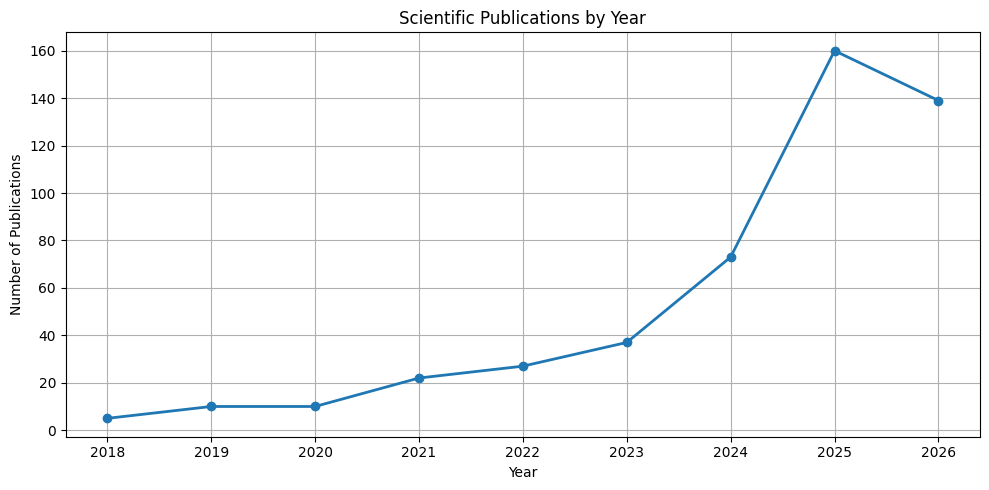

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    publications["Year"],
    publications["Publications"],
    marker="o",
    linewidth=2
)

plt.title("Scientific Publications by Year")
plt.xlabel("Year")
plt.ylabel("Number of Publications")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "publication_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [11]:
X = publications[["Year"]]

y = publications["Publications"]

model = LinearRegression()

model.fit(X, y)

print("="*60)
print("Machine Learning model trained successfully")
print("="*60)

Machine Learning model trained successfully


In [12]:
future_years = pd.DataFrame({
    "Year": np.arange(
        publications["Year"].min(),
        2031
    )
})

future_years["Prediction"] = model.predict(future_years)

future_years.tail(10)

,Year,Prediction
3,2021,34.883333
4,2022,53.666667
5,2023,72.450000
6,2024,91.233333
7,2025,110.016667
8,2026,128.800000
9,2027,147.583333
10,2028,166.366667
11,2029,185.150000
12,2030,203.933333


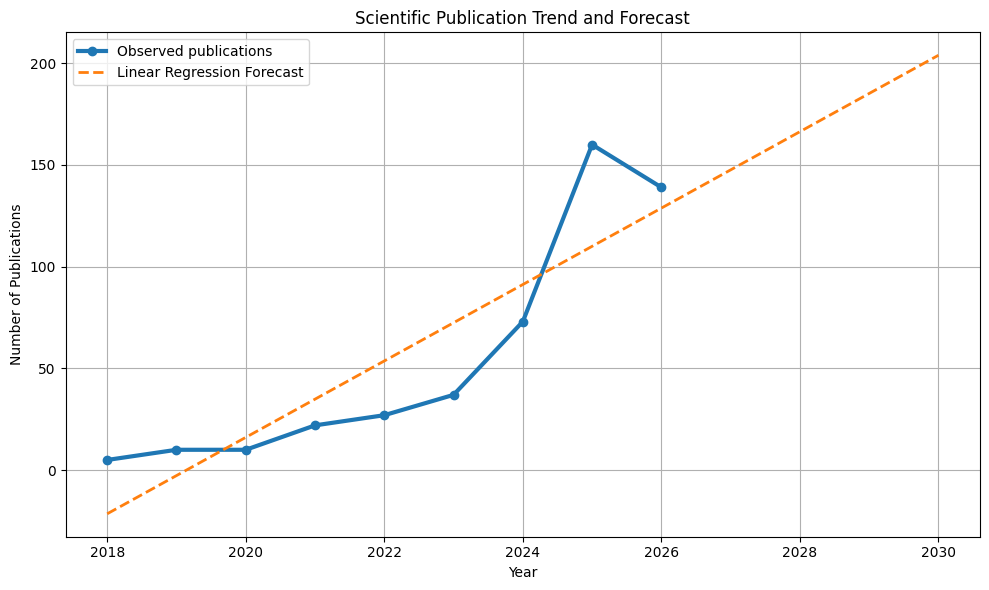

In [13]:
plt.figure(figsize=(10,6))

# Datos históricos
plt.plot(
    publications["Year"],
    publications["Publications"],
    marker="o",
    linewidth=3,
    label="Observed publications"
)

# Predicción
plt.plot(
    future_years["Year"],
    future_years["Prediction"],
    linestyle="--",
    linewidth=2,
    label="Linear Regression Forecast"
)

plt.title("Scientific Publication Trend and Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Publications")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "forecast_publications.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
from scipy.stats import norm
import numpy as np

In [15]:
media = publications["Publications"].mean()
desviacion = publications["Publications"].std()

print("Mean:", round(media,2))
print("Std:", round(desviacion,2))

Mean: 53.67
Std: 58.24


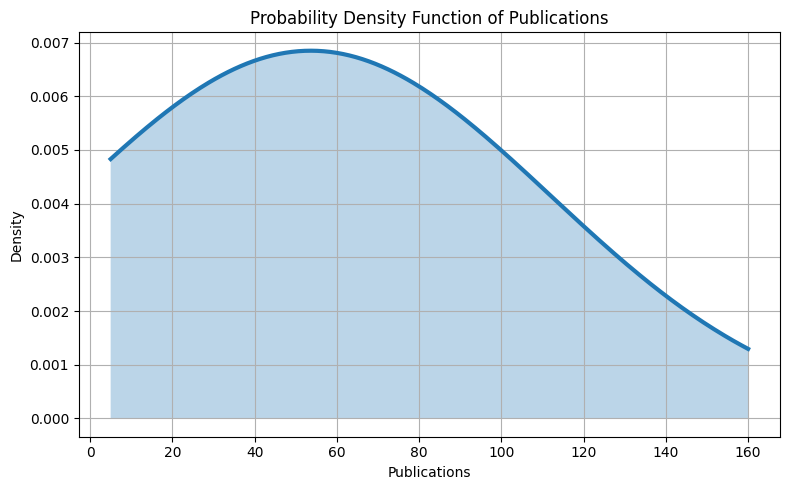

In [16]:
x = np.linspace(
    publications["Publications"].min(),
    publications["Publications"].max(),
    300
)

pdf = norm.pdf(
    x,
    media,
    desviacion
)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    pdf,
    linewidth=3
)

plt.fill_between(
    x,
    pdf,
    alpha=0.30
)

plt.title("Probability Density Function of Publications")

plt.xlabel("Publications")

plt.ylabel("Density")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "pdf_publications.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

future_years["RF_Prediction"] = rf.predict(
    future_years[["Year"]]
)

future_years.tail()

,Year,Prediction,RF_Prediction
8,2026,128.800000,135.443333
9,2027,147.583333,135.443333
10,2028,166.366667,135.443333
11,2029,185.150000,135.443333
12,2030,203.933333,135.443333


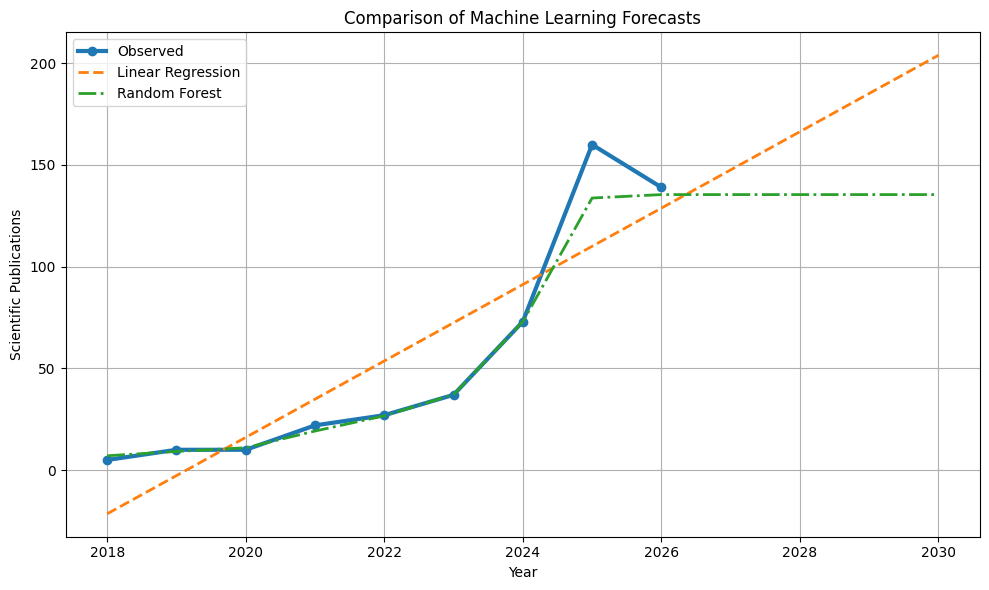

In [21]:
plt.figure(figsize=(10,6))

plt.plot(
    publications["Year"],
    publications["Publications"],
    marker="o",
    linewidth=3,
    label="Observed"
)

plt.plot(
    future_years["Year"],
    future_years["Prediction"],
    linestyle="--",
    linewidth=2,
    label="Linear Regression"
)

plt.plot(
    future_years["Year"],
    future_years["RF_Prediction"],
    linestyle="-.",
    linewidth=2,
    label="Random Forest"
)

plt.title("Comparison of Machine Learning Forecasts")

plt.xlabel("Year")
plt.ylabel("Scientific Publications")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "ml_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

linear_mae = mean_absolute_error(
    y,
    model.predict(X)
)

rf_mae = mean_absolute_error(
    y,
    rf.predict(X)
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y,
        model.predict(X)
    )
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y,
        rf.predict(X)
    )
)

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        linear_mae,
        rf_mae
    ],

    "RMSE":[
        linear_rmse,
        rf_rmse
    ]

})

results

,Model,MAE,RMSE
0,Linear Regression,22.074074,25.749182
1,Random Forest,4.110741,8.915171
